In [5]:
import numpy as np
from astropy import units as u
from astropy.table import Table
from astropy.time import Time
from WDBinary import WDBinary

from scipy import integrate
from astropy.constants import G, c, M_sun

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

WD masses in binary systems range from 0.8 - 1.14 solar masses, and avg radius is 0.01 solar radii
NS avg mass 1.4 solar masses, avg radius is 15km
BH masses (stellar-mass) 5-150 solar masses, (radius around 30 km for 10 solar masses)


In [6]:
N = 5000
m_wd = 0.63
m_s = 1.1
r_wd = 0.0133 * u.R_sun 
r_s = 1.0 * u.R_sun
a = 10 * u.R_sun
e = 0 #0.061
period = 683.267 
L_star = 1.0
L_wd = 0.001
t = np.linspace(0, (period*u.day).to(u.yr).value, N) * u.yr
d = 50 * u.pc
inc = 90 *u.deg

prob something with E calculation

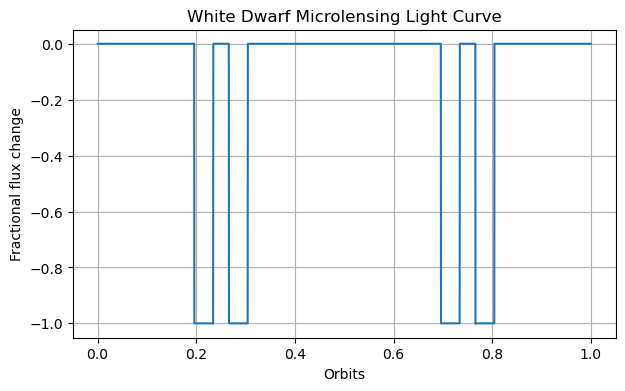

In [7]:
test1 = WDBinary(m_wd, r_wd, L_wd, m_s, r_s, L_star, e, a, d, t, inc=inc, period=period)
test1.plot_light_curve(t)

## MC Calcualtion ##

In [150]:
def einstein_radius_circ(M, a, D):
    r_E = np.sqrt((2 * G * M * a) / (c**2 * D * (D + a)))
    return (r_E * D).to(u.Rsun)
    
def transit_prob(r_E, r_star, a):
    return (r_E + r_star) / a

In [151]:
def sample_rstar_from_mstar(Mstar, N, sigma_logR=0.1):
    if Mstar.value < 1.0:
        alpha = 0.8
    elif Mstar.value < 10.0:
        alpha = 0.57
    else:
        alpha = 0.3

    Rmean = Mstar.value**alpha
    logR = np.log10(Rmean) + np.random.normal(0, sigma_logR, N)
    return 10**logR * u.Rsun

def sample_cosi(N):
    return np.random.uniform(0, 1, N)

def transit_condition(a, cosi, Rstar, rE):
    r = a * cosi

    if Rstar.size > 1:
        rE_arr = rE

        if rE.size == 1:
            rE_arr = np.ones(Rstar.size) * rE
        
        cond = Rstar + rE_arr

    return r < cond

In [152]:
def transit_prob_Mlens(a, Mstar, Mlens, D, N=100000,sigma_logR=0.1):
    Rstar = sample_rstar_from_mstar(Mstar, N, sigma_logR)
    cosi = sample_cosi(N)
    rE = einstein_radius_circ(Mlens, a, D)

    obs = transit_condition(a, cosi, Rstar, rE)
    return np.sum(obs), obs.size

In [153]:
def transit_prob_a(a, Mstar, Mlens, D, N=100000,sigma_logR=0.1):
    Rstar = sample_rstar_from_mstar(Mstar, N, sigma_logR)
    cosi = sample_cosi(N)
    rE = einstein_radius_circ(Mlens, a, D)

    obs = transit_condition(a, cosi, Rstar, rE)
    return np.sum(obs), obs.size

In [154]:
def transit_prob_Rstar(a, Mstar, Mlens, D, N=100000,sigma_logR=0.1):
    cosi = sample_cosi(N)
    rE = einstein_radius_circ(Mlens, a, D)

    obs = transit_condition(a, cosi, Rstar, rE)
    return np.sum(obs), obs.size

In [155]:
a_vals = np.logspace(-2, 1, 50) * u.au

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=0.6*u.Msun, D=26.8*u.kpc)
           for a in a_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(a_vals)


[0.47797 0.41633 0.36068 0.31453 0.2735  0.23768 0.20715 0.17852 0.15591
 0.13446 0.11766 0.10346 0.08883 0.07665 0.06749 0.05703 0.05004 0.04407
 0.03865 0.03268 0.02866 0.02513 0.02085 0.0183  0.01587 0.0143  0.01208
 0.01091 0.00911 0.00829 0.00693 0.006   0.00566 0.00441 0.00416 0.00353
 0.00333 0.00279 0.00199 0.00209 0.00189 0.00152 0.00148 0.0012  0.00107
 0.001   0.00089 0.00071 0.00058 0.00068]
[47797 41633 36068 31453 27350 23768 20715 17852 15591 13446 11766 10346
  8883  7665  6749  5703  5004  4407  3865  3268  2866  2513  2085  1830
  1587  1430  1208  1091   911   829   693   600   566   441   416   353
   333   279   199   209   189   152   148   120   107   100    89    71
    58    68]
[ 0.01        0.01151395  0.01325711  0.01526418  0.01757511  0.0202359
  0.02329952  0.02682696  0.03088844  0.0355648   0.04094915  0.04714866
  0.05428675  0.06250552  0.07196857  0.08286428  0.09540955  0.10985411
  0.12648552  0.14563485  0.16768329  0.19306977  0.22229965  0.25595

Text(0.5, 0, 'a (AU)')

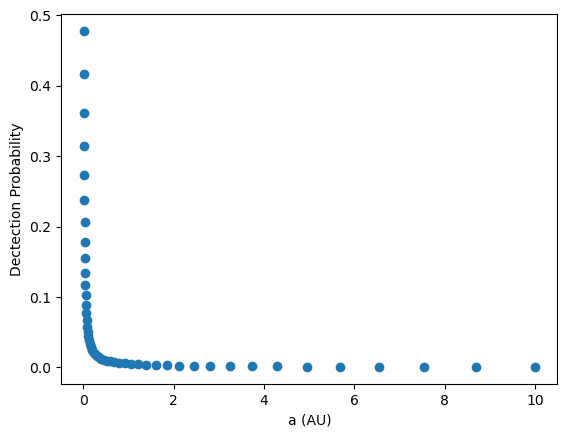

In [156]:
plt.scatter(a_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("a (AU)")

In [157]:
Mlens_vals = np.linspace(0.1, 10, 1000) * u.Msun
a = 1.0 * u.au

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=Ml, D=26.8*u.kpc)
           for Ml in Mlens_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(Mlens_vals)

[0.00487 0.00493 0.00487 0.00506 0.00477 0.00464 0.00486 0.00506 0.00497
 0.00441 0.00493 0.00501 0.00485 0.00487 0.00514 0.00481 0.00489 0.0048
 0.0049  0.00444 0.00452 0.00478 0.0048  0.00482 0.00485 0.00491 0.00484
 0.00484 0.00451 0.0049  0.00486 0.00505 0.00462 0.00435 0.00468 0.00472
 0.00457 0.00522 0.00475 0.00523 0.005   0.00434 0.00476 0.00497 0.00499
 0.00493 0.00503 0.00452 0.00439 0.00505 0.00488 0.00507 0.00449 0.00484
 0.00496 0.005   0.00548 0.00512 0.00444 0.00513 0.00503 0.00494 0.00483
 0.00458 0.00472 0.00487 0.00469 0.00481 0.00513 0.00492 0.00475 0.00501
 0.00517 0.00528 0.00448 0.00465 0.00413 0.00455 0.005   0.00512 0.00525
 0.00507 0.00501 0.00463 0.00464 0.00457 0.00454 0.00487 0.00501 0.00494
 0.00481 0.00492 0.00497 0.00464 0.00515 0.00479 0.0046  0.0046  0.00444
 0.00518 0.00479 0.00492 0.0048  0.00499 0.0048  0.0048  0.00462 0.00504
 0.00494 0.0047  0.00516 0.00512 0.00519 0.00493 0.00442 0.00503 0.00484
 0.00488 0.00527 0.00513 0.00495 0.00426 0.0052  0.0

Text(0.5, 0, '$M_\\mathrm{lens} (M_\\odot)$')

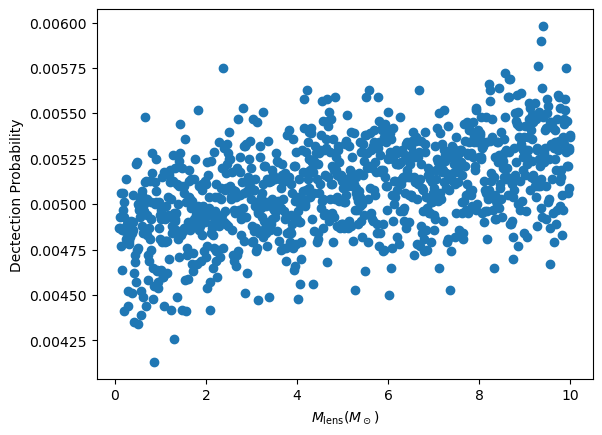

In [158]:
plt.scatter(Mlens_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("$M_\mathrm{lens} (M_\odot)$")

In [159]:
Mstar_vals = np.linspace(0.2, 5, 1000) * u.Msun
a = 1.0 * u.au

results = [transit_prob_a(a, Mstar=M, Mlens=0.6*u.Msun, D=26.8*u.kpc)
           for M in Mstar_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(Mstar_vals)


[0.00145 0.00147 0.0015  0.00147 0.00153 0.00149 0.00145 0.00167 0.00152
 0.00186 0.00137 0.00183 0.00159 0.00186 0.00187 0.00168 0.00184 0.00173
 0.00194 0.00203 0.00195 0.00179 0.00176 0.00215 0.00192 0.00211 0.00237
 0.00208 0.00228 0.00193 0.00212 0.00208 0.00196 0.0024  0.00224 0.00223
 0.00226 0.00216 0.00221 0.00235 0.00238 0.00239 0.00265 0.00237 0.00264
 0.00242 0.00222 0.00269 0.00275 0.00262 0.00277 0.0026  0.0026  0.00249
 0.00262 0.00273 0.00271 0.00262 0.00279 0.00278 0.003   0.00302 0.00257
 0.00276 0.00293 0.00283 0.00305 0.00295 0.00299 0.00312 0.00306 0.00328
 0.00283 0.00296 0.00317 0.00311 0.00305 0.00315 0.00317 0.00351 0.00324
 0.00325 0.00344 0.00353 0.00329 0.0037  0.00308 0.00337 0.00339 0.00341
 0.0033  0.00337 0.00334 0.00355 0.00368 0.00384 0.0036  0.00353 0.00402
 0.00346 0.00396 0.00378 0.00368 0.00332 0.00358 0.00365 0.00386 0.00415
 0.00381 0.00382 0.00384 0.00386 0.0038  0.00377 0.00377 0.00387 0.00389
 0.00359 0.00396 0.0042  0.00382 0.0041  0.00412 0.

Text(0.5, 0, '$M_\\mathrm{*} (M_\\odot)$')

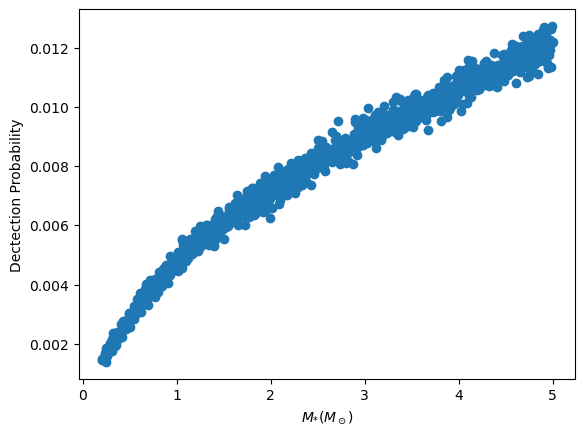

In [160]:
plt.scatter(Mstar_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("$M_\mathrm{*} (M_\odot)$")

## BH SLB DETECABILITY RECALCULATION ##

In [161]:
def sample_bh_masses(N, m_min=5.0, m_max=50.0, alpha=2.3):
    inv = 1.0 - alpha
    c0 = m_min**inv
    c1 = m_max**inv
    r = np.random.rand(N)
    masses = (c0 + (c1 - c0)*r)**(1.0/inv)
    return masses

# replace your linspace with this:
Mlens_vals = sample_bh_masses(1000) * u.Msun
a = 1.0 * u.au

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=Ml, D=26.8*u.kpc)
           for Ml in Mlens_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(Mlens_vals)

[0.00547 0.00465 0.00537 0.00494 0.00492 0.00512 0.00535 0.00528 0.00552
 0.00535 0.00554 0.00512 0.00546 0.00529 0.00551 0.0051  0.00507 0.00505
 0.005   0.00526 0.00516 0.00572 0.00535 0.00518 0.00538 0.00522 0.00538
 0.00536 0.00505 0.0056  0.00522 0.00526 0.00549 0.00534 0.0053  0.00534
 0.00522 0.00539 0.00505 0.0054  0.00542 0.00517 0.00483 0.00519 0.00556
 0.00474 0.00534 0.00521 0.00542 0.00573 0.00556 0.00518 0.00512 0.0054
 0.00502 0.0049  0.00506 0.00478 0.00516 0.00492 0.00502 0.00512 0.00491
 0.00506 0.00507 0.00537 0.00465 0.00519 0.00543 0.00514 0.00557 0.00506
 0.0047  0.00537 0.0053  0.00554 0.0052  0.00535 0.00481 0.00503 0.00541
 0.00521 0.00547 0.00471 0.00548 0.0049  0.00504 0.0057  0.0055  0.00489
 0.00506 0.00572 0.00496 0.00523 0.00526 0.00534 0.00555 0.00541 0.00527
 0.00561 0.00528 0.00531 0.00505 0.00571 0.00529 0.0054  0.00494 0.00569
 0.00552 0.00556 0.00525 0.00515 0.00497 0.00508 0.00493 0.0048  0.00508
 0.00544 0.00499 0.00503 0.00499 0.00499 0.00541 0.0

Text(0.5, 0, '$M_\\mathrm{lens} (M_\\odot)$')

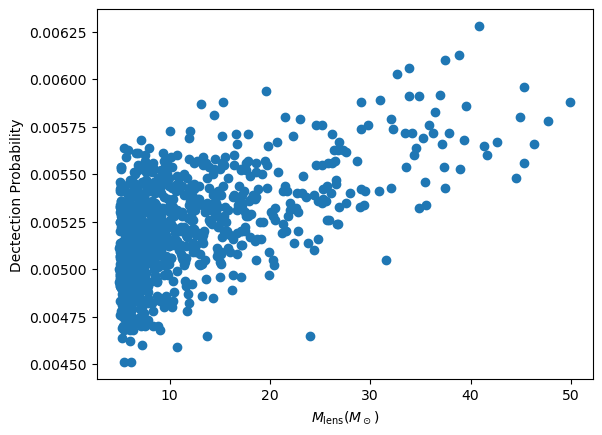

In [162]:
plt.scatter(Mlens_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("$M_\mathrm{lens} (M_\odot)$")

In [163]:
a_vals = []
while len(a_vals) < 100:
    x = np.random.normal(4.96, 2.5, 100)
    a_vals = np.concatenate([a_vals, x[(x>=1.40)&(x<=16.55)]])
a_vals = np.array(a_vals[:100]) * u.AU

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=10*u.Msun, D=26.8*u.kpc)
           for a in a_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(a_vals)

[0.00079 0.00117 0.00083 0.00073 0.00072 0.00178 0.00111 0.00061 0.00121
 0.00133 0.00062 0.00094 0.00076 0.00198 0.00235 0.00092 0.00134 0.00118
 0.00082 0.0009  0.00087 0.00133 0.00075 0.00188 0.00084 0.00155 0.00071
 0.00124 0.00186 0.00128 0.00132 0.00122 0.00182 0.00153 0.00091 0.00218
 0.00107 0.00125 0.00184 0.00059 0.00071 0.001   0.00168 0.00105 0.00075
 0.00064 0.0016  0.00058 0.00334 0.001   0.00103 0.00097 0.00224 0.00109
 0.00203 0.00109 0.0018  0.00111 0.00069 0.00338 0.00119 0.00077 0.00071
 0.00195 0.00079 0.00108 0.00127 0.00117 0.00061 0.00065 0.00087 0.00072
 0.00154 0.00112 0.00215 0.00079 0.00157 0.00145 0.00125 0.0016  0.0017
 0.00052 0.00107 0.00137 0.0007  0.00092 0.00135 0.00075 0.00219 0.00089
 0.00215 0.00091 0.00272 0.00285 0.00215 0.00143 0.0007  0.00076 0.00093
 0.00061]
[ 79 117  83  73  72 178 111  61 121 133  62  94  76 198 235  92 134 118
  82  90  87 133  75 188  84 155  71 124 186 128 132 122 182 153  91 218
 107 125 184  59  71 100 168 105  75  64 1

Text(0.5, 0, 'a (AU)')

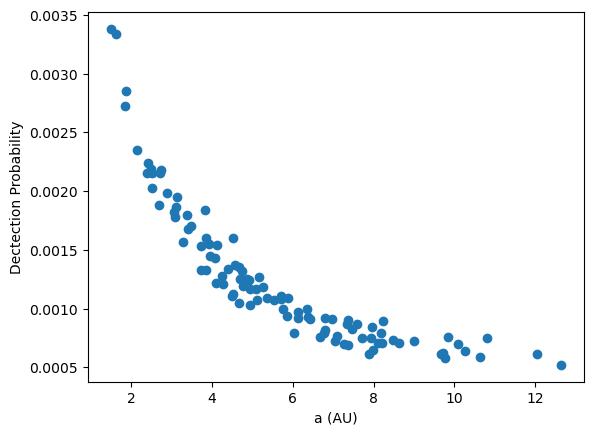

In [164]:
plt.scatter(a_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("a (AU)")

## NS SLB DETECTABILITY CALCULATION ##

In [170]:
def sample_ns_masses(N, mu=1.4, sigma=0.15, m_min=1.0, m_max=2.3):
    """
    Sample neutron star masses from a truncated normal distribution.
    Units: solar masses.
    """
    masses = np.random.normal(mu, sigma, N)

    # reject unphysical values
    mask = (masses < m_min) | (masses > m_max)
    while np.any(mask):
        masses[mask] = np.random.normal(mu, sigma, np.sum(mask))
        mask = (masses < m_min) | (masses > m_max)

    return masses

Mlens_vals = sample_ns_masses(1000) * u.Msun
a = 0.021 * u.au

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=Ml, D=26.8*u.kpc)
           for Ml in Mlens_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(Mlens_vals)

[0.22876 0.23046 0.22994 0.22875 0.23032 0.22832 0.23149 0.22953 0.22871
 0.228   0.22512 0.22899 0.22655 0.23028 0.22646 0.22739 0.22911 0.228
 0.22626 0.22545 0.22901 0.22772 0.22797 0.22643 0.22868 0.22727 0.23109
 0.2292  0.22797 0.22963 0.23069 0.22621 0.22998 0.22821 0.22783 0.22787
 0.2288  0.22865 0.22738 0.22474 0.22699 0.23021 0.22906 0.22808 0.22739
 0.22825 0.22788 0.22968 0.22718 0.22888 0.23042 0.22854 0.22768 0.22763
 0.22802 0.22959 0.22734 0.22733 0.22894 0.22963 0.22887 0.22771 0.22843
 0.22618 0.22726 0.22854 0.22901 0.22861 0.22808 0.22716 0.22968 0.22932
 0.22964 0.22802 0.22848 0.22737 0.23038 0.23007 0.23069 0.22749 0.23019
 0.22757 0.22775 0.22845 0.22792 0.22711 0.22869 0.22948 0.22768 0.22756
 0.2288  0.22967 0.23077 0.22735 0.23035 0.22992 0.22897 0.22919 0.22783
 0.22962 0.22973 0.22813 0.23041 0.22931 0.22705 0.22894 0.22767 0.22574
 0.22883 0.22982 0.22793 0.22878 0.22766 0.22969 0.22806 0.22893 0.22801
 0.22915 0.22622 0.22988 0.22701 0.23082 0.22824 0.22

Text(0.5, 0, '$M_\\mathrm{lens} (M_\\odot)$')

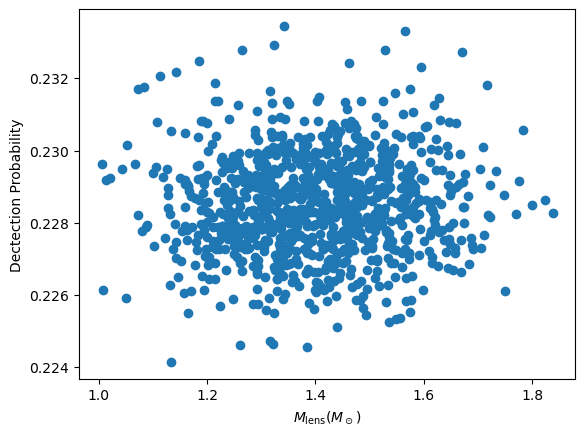

In [171]:
plt.scatter(Mlens_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("$M_\mathrm{lens} (M_\odot)$")

In [184]:
a_vals = []
while len(a_vals) < 100:
    x = np.random.normal(0.02, 0.008, 1000)  # AU
    a_vals = np.concatenate([a_vals, x[(x>=0.003)&(x<=0.08)]])
a_vals = np.array(a_vals[:100]) * u.AU

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=1.4*u.Msun, D=26.8*u.kpc)
           for a in a_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(a_vals)

[0.20727 0.46432 0.26079 0.98059 0.48426 0.12048 0.38721 0.23644 0.23138
 0.18363 0.19811 0.32735 0.23287 0.59926 0.2323  0.48829 0.15211 0.25111
 0.16271 0.21986 0.21233 0.28571 0.22488 0.5916  0.23535 0.15137 0.64023
 0.28657 0.22192 0.24598 0.37006 0.2108  0.35447 0.26753 0.20026 0.25505
 0.26886 0.22784 0.21442 0.17457 0.21372 0.25929 0.26848 0.33522 0.24605
 0.22938 0.1835  0.20174 0.17115 0.20416 0.2052  0.26569 0.29313 0.32367
 0.20967 0.23883 0.35648 0.63762 0.31593 0.98391 0.24089 0.56768 0.24316
 0.20849 0.22577 0.16393 0.23932 0.4559  0.28085 0.36665 0.16724 0.18091
 0.2204  0.36074 0.21507 0.19886 0.10156 0.27713 0.22103 0.21215 0.74208
 0.32741 0.16209 0.36862 0.33155 0.27345 0.12971 0.24283 0.18123 0.32262
 0.22897 0.14377 0.24513 0.19541 0.34168 0.19273 0.30063 0.46262 0.18292
 0.17203]
[20727 46432 26079 98059 48426 12048 38721 23644 23138 18363 19811 32735
 23287 59926 23230 48829 15211 25111 16271 21986 21233 28571 22488 59160
 23535 15137 64023 28657 22192 24598 3700

Text(0.5, 0, 'a (AU)')

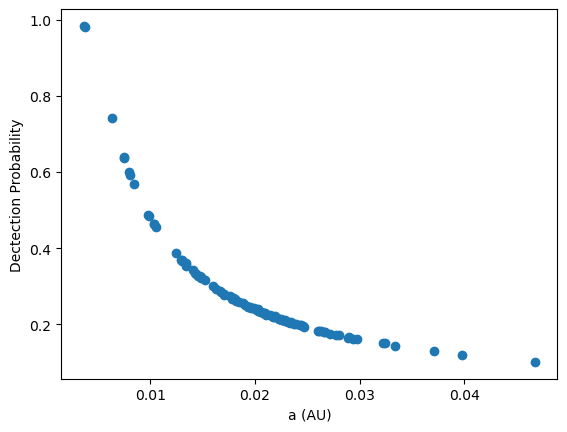

In [185]:
plt.scatter(a_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("a (AU)")

## WD SLB DETECTABILITY CALCULATION ##

In [186]:
a_vals = []
while len(a_vals) < 100:
    x = np.random.normal(0.46, 0.05, 1000)
    a_vals = np.concatenate([a_vals, x[(x>=0.05)&(x<=1.3)]])
a_vals = np.array(a_vals[:100]) * u.AU

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=0.63*u.Msun, D=26.8*u.kpc)
           for a in a_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(a_vals)

[0.01082 0.01106 0.01281 0.00951 0.01035 0.01118 0.01101 0.01261 0.01205
 0.01025 0.01047 0.00967 0.01058 0.00955 0.01162 0.01074 0.01134 0.01122
 0.01174 0.00997 0.01054 0.01114 0.01096 0.00954 0.01198 0.0108  0.00901
 0.01155 0.01058 0.0089  0.01284 0.0088  0.00979 0.01035 0.00975 0.01105
 0.01045 0.01164 0.00984 0.01121 0.01075 0.01141 0.01085 0.00925 0.01095
 0.01004 0.01015 0.01103 0.01019 0.01152 0.01075 0.0104  0.01194 0.01115
 0.01082 0.01127 0.00987 0.00974 0.01149 0.01241 0.01074 0.00988 0.01144
 0.00917 0.00959 0.01037 0.01218 0.01245 0.00849 0.00988 0.00985 0.01194
 0.00816 0.00951 0.01038 0.01098 0.00918 0.00906 0.01123 0.01184 0.01076
 0.01192 0.00927 0.01029 0.01341 0.0094  0.00829 0.01316 0.00907 0.00957
 0.01065 0.00917 0.013   0.01163 0.01097 0.01098 0.01151 0.01078 0.01267
 0.01179]
[1082 1106 1281  951 1035 1118 1101 1261 1205 1025 1047  967 1058  955
 1162 1074 1134 1122 1174  997 1054 1114 1096  954 1198 1080  901 1155
 1058  890 1284  880  979 1035  975 1105 1045

Text(0.5, 0, 'a (AU)')

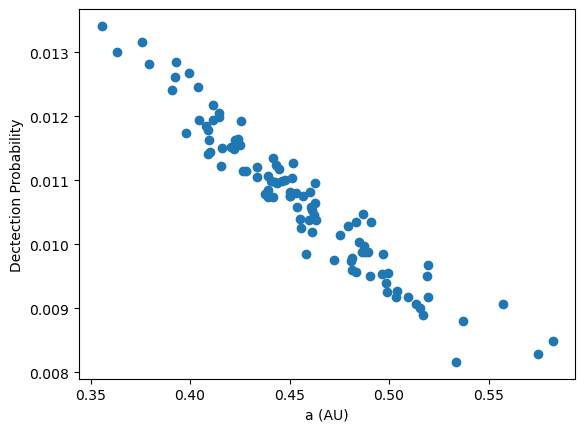

In [187]:
plt.scatter(a_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("a (AU)")